# 1.Dataset Design
inspect missing values, invalid ranges, duplicate sessions, extreme observations, and whether your variables have
sensible relationships

In [40]:
import pandas as pd
import numpy as np

df = pd.read_csv("developer_productivity.csv")  

In [41]:
df.shape

(400, 13)

the (400,13) shows that the data has 400 rows (entries) and 13 columns. for inspect more and know about the columns and entries, I will use **df.columns** to see the existing all columns in dataset and **df.head()** or also **df.tail()** to inspect some values of the dataset


In [42]:
print(f"Data Cols:{df.columns}\n")

print(f"Some Dataset's data: {df.head()}")

Data Cols:Index(['session_id', 'date', 'day', 'start_hour', 'duration_min',
       'interruptions', 'meeting_overlap', 'caffeine', 'focus', 'energy',
       'tasks_completed', 'bugs_introduced', 'productivity'],
      dtype='object')

Some Dataset's data:   session_id        date        day  start_hour  duration_min  interruptions  \
0       S104  2026-04-01  Wednesday          13            93              2   
1       S381  2026-04-01  Wednesday          13           124              2   
2       S303  2026-04-02   Thursday          18            74              1   
3       S369  2026-04-03     Friday          12            67              0   
4       S272  2026-04-03     Friday          13            59              3   

   meeting_overlap  caffeine  focus  energy  tasks_completed  bugs_introduced  \
0                0       0.0    7.0     6.0                6                1   
1                0       1.0    6.0     5.0                7                1   
2                0  

## Inspect missing values

In [43]:
missing = pd.DataFrame({
    "missing_count": df.isna().sum(),
    "missing_percent": df.isna().mean() * 100
})

missing

,missing_count,missing_percent
session_id,0,0.0
date,0,0.0
day,0,0.0
start_hour,0,0.0
duration_min,0,0.0
interruptions,0,0.0
meeting_overlap,0,0.0
caffeine,6,1.5
focus,6,1.5
energy,6,1.5


In [44]:
df[df["focus"].isna()]

,session_id,date,day,start_hour,duration_min,interruptions,meeting_overlap,caffeine,focus,energy,tasks_completed,bugs_introduced,productivity
8,S138,2026-04-04,Saturday,15,70,2,0,0.0,NaN,4.0,7,0,84.8
17,S150,2026-04-08,Wednesday,9,95,1,0,1.0,NaN,9.0,8,0,91.9
159,S373,2026-05-21,Thursday,13,20,0,0,1.0,NaN,7.0,4,0,76.9
199,S282,2026-05-30,Saturday,10,46,1,0,1.0,NaN,7.0,5,0,94.7
230,S126,2026-06-08,Monday,15,52,2,0,1.0,NaN,10.0,5,2,83.6
258,S123,2026-06-19,Friday,11,85,1,0,1.0,NaN,10.0,9,1,100.0


My observation: They are spread across different dates, days and etc, so there is no  pattern suggesting that the missing values are concentrated in a particular type of session.

In [45]:
df[df["energy"].isna()]

,session_id,date,day,start_hour,duration_min,interruptions,meeting_overlap,caffeine,focus,energy,tasks_completed,bugs_introduced,productivity
88,S363,2026-04-28,Tuesday,17,94,1,0,0.0,6.0,NaN,4,0,92.6
105,S281,2026-05-04,Monday,12,84,3,0,1.0,7.0,NaN,6,1,91.7
109,S314,2026-05-05,Tuesday,11,71,2,0,1.0,7.0,NaN,5,1,73.9
151,S374,2026-05-16,Saturday,16,37,4,1,0.0,6.0,NaN,4,0,55.8
298,S059,2026-06-30,Tuesday,9,83,1,0,1.0,7.0,NaN,8,1,100.0
335,S166,2026-07-09,Thursday,12,53,1,0,1.0,5.0,NaN,3,0,81.3


My observation: it seems that the missing values of the energy is depending on the interruption, so when the energy value is missed, must be at least one intterupt accured during the session. 

In [46]:
df[df["caffeine"].isna()]



,session_id,date,day,start_hour,duration_min,interruptions,meeting_overlap,caffeine,focus,energy,tasks_completed,bugs_introduced,productivity
75,S023,2026-04-23,Thursday,15,36,0,0,NaN,7.0,8.0,5,0,75.7
110,S299,2026-05-05,Tuesday,12,32,0,0,NaN,7.0,3.0,5,2,87.5
111,S399,2026-05-05,Tuesday,20,42,3,0,NaN,6.0,4.0,3,0,56.7
153,S188,2026-05-17,Sunday,18,82,3,0,NaN,5.0,8.0,5,2,71.4
309,S089,2026-07-03,Friday,13,37,0,1,NaN,6.0,8.0,6,2,68.3
353,S232,2026-07-14,Tuesday,16,68,2,0,NaN,10.0,7.0,7,0,82.9


My observation: All of the missed caffeine values is about the sessions have holded in afternoon (or not morning).

## Understand the data types

In [47]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 400 entries, 0 to 399
Data columns (total 13 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   session_id       400 non-null    object 
 1   date             400 non-null    object 
 2   day              400 non-null    object 
 3   start_hour       400 non-null    int64  
 4   duration_min     400 non-null    int64  
 5   interruptions    400 non-null    int64  
 6   meeting_overlap  400 non-null    int64  
 7   caffeine         394 non-null    float64
 8   focus            394 non-null    float64
 9   energy           394 non-null    float64
 10  tasks_completed  400 non-null    int64  
 11  bugs_introduced  400 non-null    int64  
 12  productivity     400 non-null    float64
dtypes: float64(4), int64(6), object(3)
memory usage: 40.8+ KB


In [48]:
#convert date type from object to datetime
df["date"] = pd.to_datetime(df["date"])

#convert caffeine type from float to bool

df["caffeine"] = (
    df["caffeine"]
    .map({1.0: True, 0.0: False})
    .astype("boolean")
)

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 400 entries, 0 to 399
Data columns (total 13 columns):
 #   Column           Non-Null Count  Dtype         
---  ------           --------------  -----         
 0   session_id       400 non-null    object        
 1   date             400 non-null    datetime64[ns]
 2   day              400 non-null    object        
 3   start_hour       400 non-null    int64         
 4   duration_min     400 non-null    int64         
 5   interruptions    400 non-null    int64         
 6   meeting_overlap  400 non-null    int64         
 7   caffeine         394 non-null    boolean       
 8   focus            394 non-null    float64       
 9   energy           394 non-null    float64       
 10  tasks_completed  400 non-null    int64         
 11  bugs_introduced  400 non-null    int64         
 12  productivity     400 non-null    float64       
dtypes: boolean(1), datetime64[ns](1), float64(3), int64(6), object(2)
memory usage: 38.4+ KB


note: replacing float64 to boolean in caffeine value reduced the memory usage.

## Check invalid ranges

| Variable          | Expected range |
| ----------------- | -------------- |
| `start_hour`      | 0–23           |
| `duration_min`    | > 0            |
| `interruptions`   | ≥ 0            |
| `meeting_overlap` | 0 or 1         |
| `caffeine`        | 0 or 1         |
| `focus`           | 1–10           |
| `energy`          | 1–10           |
| `tasks_completed` | ≥ 0            |
| `bugs_introduced` | ≥ 0            |
| `productivity`    | 0–100          |


In [49]:
invalid_valeus = {}

invalid_valeus["start_hour"] = df[(df["start_hour"] > 24) | (df["start_hour"] < 0)]
invalid_valeus["duration_min"] = df[df["duration_min"] < 1]
invalid_valeus["interruptions"] = df[df["interruptions"] < 0]
invalid_valeus["meeting_overlap"] = df[~df["meeting_overlap"].isin([0, 1])]
invalid_valeus["caffeine"] = df[~df["caffeine"].isin([True,False,pd.NA])]
invalid_valeus["focus"] = df[(df["focus"] > 10) | (df["focus"] < 0)]
invalid_valeus["energy"] = df[(df["energy"] > 10) | (df["energy"] < 0)]
invalid_valeus["task_completed"] = df[df["tasks_completed"] < 0]
invalid_valeus["bugs_introduced"] = df[df["bugs_introduced"] < 0]
invalid_valeus["productivity"] = df[(df["productivity"] > 100) | (df["productivity"] < 0)]

invalid_valeus.values



<function dict.values>

As you see there is no invalid value in dataset and all of the values are in the range of each variables

## Use the IQR idea

In [50]:
df.describe()

,date,start_hour,duration_min,interruptions,meeting_overlap,focus,energy,tasks_completed,bugs_introduced,productivity
count,400,400.000000,400.000000,400.000000,400.000000,394.000000,394.000000,400.000000,400.000000,400.000000
mean,2026-05-31 02:09:36,13.295000,77.977500,1.905000,0.155000,6.642132,6.682741,5.832500,0.682500,76.780250
min,2026-04-01 00:00:00,8.000000,20.000000,0.000000,0.000000,3.000000,2.000000,1.000000,0.000000,33.600000
25%,2026-05-03 00:00:00,11.000000,61.000000,1.000000,0.000000,6.000000,6.000000,5.000000,0.000000,68.000000
50%,2026-05-30 00:00:00,13.000000,80.000000,2.000000,0.000000,7.000000,7.000000,6.000000,1.000000,77.700000
75%,2026-06-30 06:00:00,16.000000,93.000000,3.000000,0.000000,8.000000,8.000000,7.000000,1.000000,86.225000
max,2026-07-31 00:00:00,21.000000,145.000000,8.000000,1.000000,10.000000,10.000000,11.000000,3.000000,100.000000
std,NaN,3.075976,23.497816,1.411011,0.362358,1.374560,1.502621,1.626671,0.766919,13.123254


In [51]:
q1 = df["duration_min"].quantile(0.25)
q3 = df["duration_min"].quantile(0.75)

iqr = q3 - q1

In [52]:
lower = q1 - 1.5 * iqr
upper = q3 + 1.5 * iqr

outliers = df[
    (df["duration_min"] < lower) |
    (df["duration_min"] > upper)
]

outliers

,session_id,date,day,start_hour,duration_min,interruptions,meeting_overlap,caffeine,focus,energy,tasks_completed,bugs_introduced,productivity
202,S055,2026-05-31,Sunday,11,145,6,0,True,7.0,9.0,8,1,94.7
241,S270,2026-06-12,Friday,13,145,1,0,True,6.0,7.0,7,1,83.1


An IQR outlier is not automatically an error.It means that This observation is unusual relative to the distribution.

# 2.Analyze Data and Explore Visually

In [53]:
from matplotlib import pyplot as plt

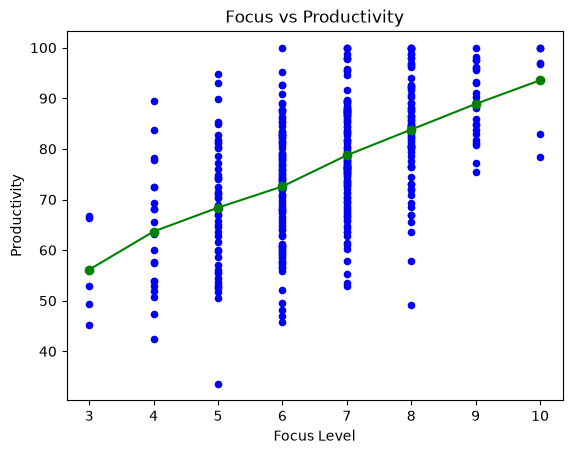

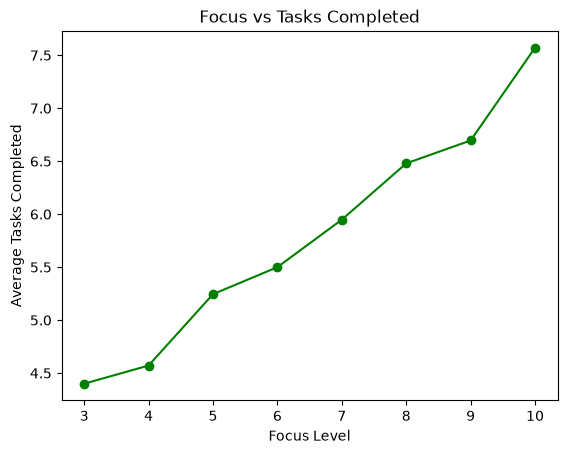

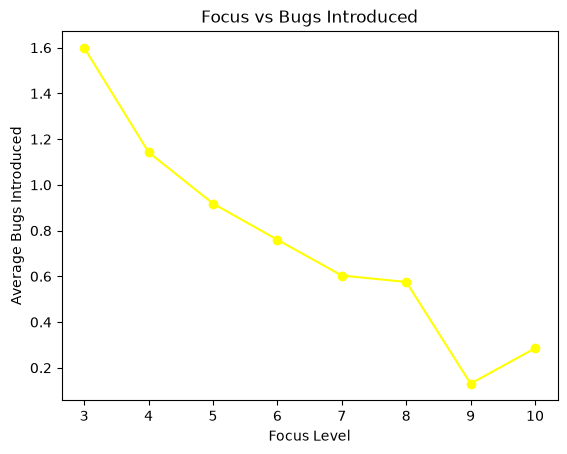

In [54]:
#the relation between focus and productivity
focus_productivity = df.groupby("focus")["productivity"].mean()

focus_levels = focus_productivity.index.to_numpy()
productivity_means = focus_productivity.values

plt.plot(focus_levels, productivity_means, color="green", marker="o")

fo = df.sort_values(by="focus", ascending=True)
plt.scatter(fo["focus"], fo["productivity"], color="blue", marker="o", s=20)

plt.title("Focus vs Productivity")
plt.xlabel("Focus Level")
plt.ylabel("Productivity")

plt.show()

focus_tasks = df.groupby("focus")["tasks_completed"].mean()

focus_levels = focus_tasks.index.to_numpy()
tasks_means = focus_tasks.values

plt.plot(focus_levels, tasks_means, color="green", marker="o")

plt.title("Focus vs Tasks Completed")
plt.xlabel("Focus Level")
plt.ylabel("Average Tasks Completed")

plt.show()

focus_bugs = df.groupby("focus")["bugs_introduced"].mean()

focus_levels = focus_bugs.index.to_numpy()
bugs_means = focus_bugs.values

plt.plot(focus_levels, bugs_means, color="yellow", marker="o")

plt.title("Focus vs Bugs Introduced")
plt.xlabel("Focus Level")
plt.ylabel("Average Bugs Introduced")

plt.show()


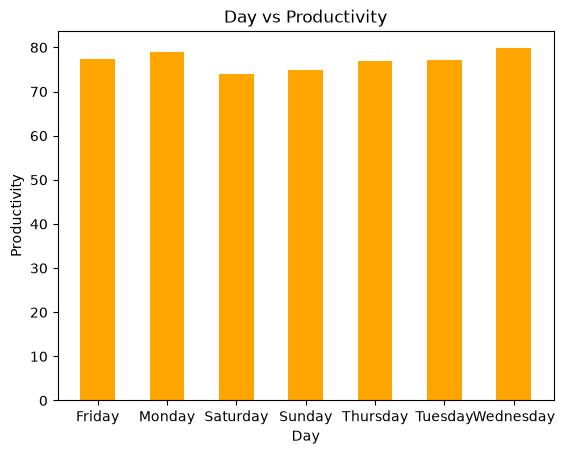

Text(0, 0.5, 'Focus')

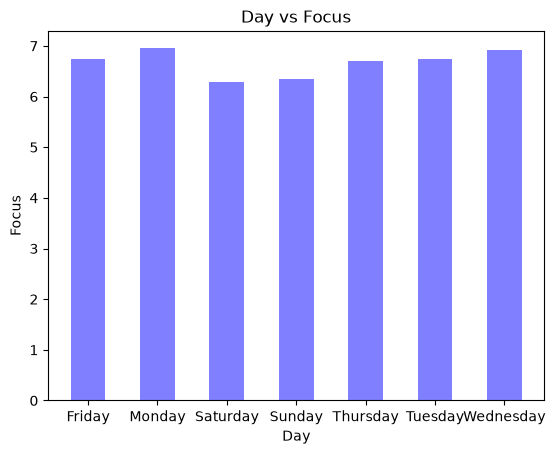

In [55]:
#the relation between day and productivity and focus
day_productivity = df.groupby("day")["productivity"].mean()

day_levels = day_productivity.index.to_numpy()
productivity_means = day_productivity.values


plt.bar(day_levels, productivity_means, color="orange", width=0.5)


plt.title("Day vs Productivity")
plt.xlabel("Day")
plt.ylabel("Productivity")

plt.show()

day_focus = df.groupby("day")["focus"].mean()
focus_means = day_focus.values

plt.bar(day_levels, focus_means, color="blue", width=0.5, alpha=0.5)
plt.title("Day vs Focus")
plt.xlabel("Day")
plt.ylabel("Focus")


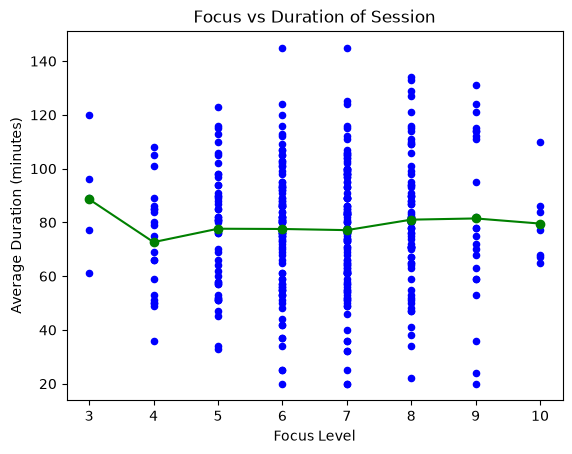

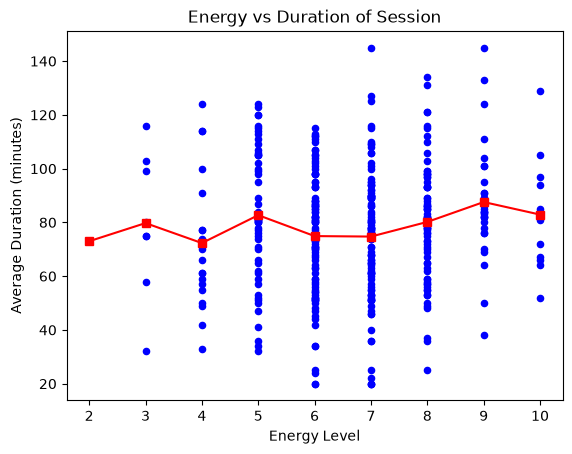

In [56]:
#the relation between duration of session and focus and energy
focus_duration_min = df.groupby("focus")["duration_min"].mean()

focus_levels = focus_duration_min.index.to_numpy()
duration_means = focus_duration_min.values

plt.plot(focus_levels, duration_means, color="green", marker="o")

fo = df.sort_values(by="focus", ascending=True)
plt.scatter(fo["focus"], fo["duration_min"], color="blue", marker="o", s=20)

plt.title("Focus vs Duration of Session")
plt.xlabel("Focus Level")
plt.ylabel("Average Duration (minutes)")

plt.show()

energy_duration_min = df.groupby("energy")["duration_min"].mean()

energy_levels = energy_duration_min.index.to_numpy()
duration_means = energy_duration_min.values

fo = df.sort_values(by="energy", ascending=True)
plt.scatter(fo["energy"], fo["duration_min"], color="blue", marker="o", s=20)

plt.plot(energy_levels, duration_means, color="red", marker="s")

plt.title("Energy vs Duration of Session")
plt.xlabel("Energy Level")
plt.ylabel("Average Duration (minutes)")

plt.show()


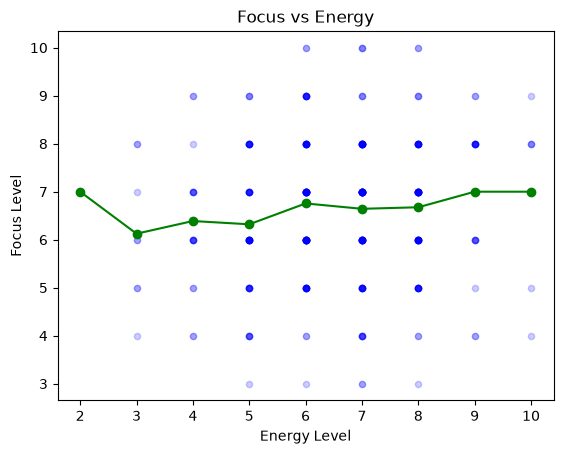

In [57]:
#the relation between focus and energy 

energy_focus = df.groupby("energy")["focus"].mean()

energy_levels = energy_focus.index.to_numpy()
focus_means = energy_focus.values

plt.plot(energy_levels, focus_means, color="green", marker="o")

fo = df.sort_values(by="energy", ascending=True)
plt.scatter(fo["energy"], fo["focus"], color="blue", marker="o", s=20,alpha=0.2)

plt.title("Focus vs Energy")
plt.xlabel("Energy Level")
plt.ylabel("Focus Level")

plt.show()

Based on the relationships among the different variables, I created several charts to explore the patterns and correlations in the data.

My main finding is that **productivity appears to be strongly related to focus**. The **number of completed tasks** and **the number of bugs introduced** also show strong relationships with focus. In general, when developers have a high level of focus during a session, they tend to complete more tasks and introduce fewer bugs.

Therefore, the data suggests that **higher levels of focus are associated with higher productivity**.

In contrast, productivity does not appear to depend on the **day of the week**. Developers may have different levels of focus and productivity on the same day of the week, suggesting that the day itself is not a strong factor in determining productivity.

I also expected **session duration** to affect developers' energy and focus levels. However, the data does not show a clear relationship between session duration and either energy or focus. This suggests that, within this dataset, longer sessions do not necessarily lead to higher or lower levels of energy and focus.


# 3.Quantify patterns
I choose important variable **Productivity** because it is the main outcome of your project.

## Central Tendencies

In [58]:
#Mean
mean = df["productivity"].mean()

#Median
median = df["productivity"].median()

mean,median

(76.78025, 77.7)

The value of mean is approximately same as median. It means that the distribution may be relatively balanced (by having a little left-skewed distribution).

In [59]:
#Mode
mode = df["productivity"].mode()[0]
mode

100.0

The value of mode represents that in the most session, the developers have the maximum productivity.

In [60]:
#Quantiles

quantiles = df["productivity"].quantile([0.2, 0.25, 0.75, 0.90])
quantiles

0.20    65.680
0.25    68.000
0.75    86.225
0.90    94.700
Name: productivity, dtype: float64

- 20% of the session have productivity below 65.68.
- 25% of the session have productivity below 68.
- 75% of the session have productivity below 86.225.
- 90% of the session have productivity below 94.7.

In [61]:
#Quantify Disperion (spread)

#The interval between highest and lowest productivity value
range = df["productivity"].max() - df["productivity"].min()

#Standard Deviation
std = df["productivity"].std()

#Variance
var = std ** 2 #or df["productivity"].var()

range,std,var

(66.4, 13.123253575180822, 172.21978439849622)

## Compare some groups

In [62]:
high_focus = df[df["focus"] > 7]
low_focus = df[df["focus"] <= 7]

high_focus["productivity"].mean(), low_focus["productivity"].mean()

(85.61456310679611, 73.40859106529209)

In [63]:
morning = df[df["start_hour"] < 12]
afternoon =  df[(df["start_hour"] >= 12) & (df["start_hour"] < 18)]
evening = df[df["start_hour"] >= 18]

morning["productivity"].mean(), afternoon["productivity"].mean(), evening["productivity"].mean()

(82.76666666666665, 73.49276018099548, 73.68684210526314)

In [64]:
morning["productivity"].std(), afternoon["productivity"].std(), evening["productivity"].std()

(11.85066403604617, 12.802007728955072, 11.847092722452855)

In [65]:
print(df.groupby("caffeine")["productivity"].mean())
print(df.groupby("energy")["productivity"].mean())

caffeine
False    73.991500
True     79.748969
Name: productivity, dtype: float64
energy
2.0     71.200000
3.0     77.587500
4.0     73.094737
5.0     75.028302
6.0     76.603191
7.0     76.205825
8.0     76.778378
9.0     81.235484
10.0    82.709091
Name: productivity, dtype: float64


In [66]:
#Covariace
covar = df[["focus","productivity"]].cov()
covar

,focus,productivity
focus,1.889416,9.866739
productivity,9.866739,172.219784


In [67]:
#Correlation
variables = [
    "focus",
    "interruptions",
    "duration_min",
    "tasks_completed",
    "bugs_introduced",
    "energy",
    "productivity"
]

df[variables].corr()


,focus,interruptions,duration_min,tasks_completed,bugs_introduced,energy,productivity
focus,1.000000,-0.053343,0.051352,0.366528,-0.288253,0.108504,0.547702
interruptions,-0.053343,1.000000,0.156560,-0.269015,0.129548,0.059791,-0.446550
duration_min,0.051352,0.156560,1.000000,0.481638,-0.014027,0.073021,0.301216
tasks_completed,0.366528,-0.269015,0.481638,1.000000,-0.006574,0.077872,0.611723
bugs_introduced,-0.288253,0.129548,-0.014027,-0.006574,1.000000,0.012448,-0.272058
energy,0.108504,0.059791,0.073021,0.077872,0.012448,1.000000,0.113318
productivity,0.547702,-0.446550,0.301216,0.611723,-0.272058,0.113318,1.000000


By this correlation table, we can observe some points:

- Completed Tasks has the strongest correlations with productivity; This means sessions with more completed tasks tend to have higher productivity.
- As we already have discoverd, focus is strongly relevant.
- Interruptions show an negative relationship and sessions with more interruptions tend to have lower productivity.
- Energy is surprisingly weak. Maybe energy measure different things and developers have their own understaning about energy (mentally, physical , ...)
- and ...

note: another information that we can extract from this table is that focus and interruptions have a weak and also negative relationship. We conclude the more interruptions in session cannot affect on focus.

In [68]:
Q1 = df["productivity"].quantile(0.25)
Q3 = df["productivity"].quantile(0.75)

IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR


outliers = df[
    (df["productivity"] < lower) |
    (df["productivity"] > upper)
]

outliers

,session_id,date,day,start_hour,duration_min,interruptions,meeting_overlap,caffeine,focus,energy,tasks_completed,bugs_introduced,productivity
160,S248,2026-05-21,Thursday,14,34,4,0,False,5.0,6.0,2,1,33.6


The outlier is such a wierd based on session duration and number of interruptions. Usually each 30-40 minute, the session gonna be interrupted so the developers can rest some minutes.
So we can delete it from dataset 

In [69]:
df_without_out = df[df["productivity"].between(lower, upper)]
(df_without_out["productivity"].mean(),df["productivity"].mean(),
 df_without_out["productivity"].median(),df["productivity"].median(),
 df_without_out["productivity"].std(),df["productivity"].std())


(76.88847117794487,
 76.78025,
 77.7,
 77.7,
 12.959783848721175,
 13.123253575180822)

The difference is very small relative to the overall scale of the productivity variable. This suggests that, for productivity, the observations identified by IQR rule do not have a meaningful effect on the mean. Removing the observations identified as outliers barely changes the mean or median, and it actually decrease the standard deviation slightly. 

# 4.Reasoning With Probability

For this sectoin I choose two events: **High Productivity** and **High Focus**

In [70]:
#A = high_productivity , B = high_focus
high_productivity = df["productivity"] >= 80
high_focus = df["focus"] >= 7

In [71]:
'''
Calculate the probability of high productivity and high focus

p(A) = number of observations where A occurs / total number of observations
p(B) = number of observations where B occurs / total number of observations

'''
p_high_productivity = high_productivity.mean() # or high_productivity.sum() / len(high_productivity)
p_high_focus = high_focus.mean() # or high_focus.sum() / len(high_focus)

p_high_productivity, p_high_focus

(0.44, 0.5475)

In [76]:
'''
Calculate P(High Productivity | High Focus) : 
Probability that a session is highly productive given that the session has high focus

P(High Productivity | High Focus) = P(High Productivity and High Focus) / P(High Focus)

'''

both_high = (
    (df["productivity"] >= 80) &
    (df["focus"] >= 7)
)

p_both_high = both_high.mean()

P_high_productivity_given_high_focus1 = p_both_high / p_high_focus

#OR

high_focus_session = df[df["focus"] >= 7]
P_high_productivity_given_high_focus2 = (high_focus_session["productivity"] >= 80).mean() # or (high_focus_session["productivity"] >= 80).sum() / len(high_focus_session)


P_high_productivity_given_high_focus1, P_high_productivity_given_high_focus2

(0.589041095890411, 0.589041095890411)

## Bayes' theorem

In [78]:

'''
Bayes gives us the reverse conditional probability: P(B∣A)

Given that a session is highly productive, what is the probability that it had high focus?
'''

p_high_focus_given_high_productivity1= p_both_high / p_high_productivity

#OR

p_high_focus_given_high_productivity2 = (
    (P_high_productivity_given_high_focus1 * p_high_focus )
    / p_high_productivity
)


p_high_focus_given_high_productivity1, p_high_focus_given_high_productivity2

(0.7329545454545455, 0.7329545454545455)

In [ ]:
# Calculate P(High Focus | High Productivity) directly from the data
high_productivity_sessions = df[
    df["productivity"] >= 80
]

direct_probability = (
    high_productivity_sessions["focus"] >= 7
).mean()

direct_probability,p_high_focus_given_high_productivity1

(0.7329545454545454, 0.7329545454545455)

In [81]:
results = pd.Series({
    "P(high productivity)": p_high_productivity,
    "P(high focus)": p_high_focus,
    "P(high productivity | high focus)": P_high_productivity_given_high_focus1,
    "P(high focus | high productivity) - Bayes": p_high_focus_given_high_productivity1,
    "P(high focus | high productivity) - Direct": direct_probability
})

results

P(high productivity)                          0.440000
P(high focus)                                 0.547500
P(high productivity | high focus)             0.589041
P(high focus | high productivity) - Bayes     0.732955
P(high focus | high productivity) - Direct    0.732955
dtype: float64

The probability of high productivity increases from 44.0% overall to 58.9% when we know the session has high focus.That's meaningful evidence that **high focus is associated with higher productivity**.
However, 58.9% is nowhere near 100%, which supports your observation that **high focus is not the only factor**.